# Exploration — NHF Flash Flood Trigger: LGA Targeting

Exploratory notebook for selecting LGAs in **Borno, Adamawa, and Yobe** (BAY states) to include in an observational flash flooding trigger funded by NHF.

Sections:
1. **2025 NHF trigger LGAs** — the six LGAs used in the 2025 flash-flood observational trigger
2. **CERF 01_geospatial_overview LGAs** — OCHA 2026 prioritized LGAs from the CERF geospatial overview

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import ocha_stratus as stratus
from dotenv import load_dotenv

from src.constants import NHF_FLASH_LGAS, PROJECT_PREFIX

load_dotenv()

True

In [11]:
# Base layers
gdf_lga  = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_adm1 = stratus.codab.load_codab_from_blob("NGA", admin_level=1)

BAY_STATES = ["Borno", "Adamawa", "Yobe"]
gdf_bay      = gdf_lga[gdf_lga["ADM1_EN"].isin(BAY_STATES)].copy()
gdf_bay_adm1 = gdf_adm1[gdf_adm1["ADM1_EN"].isin(BAY_STATES)].copy()

xmin, ymin, xmax, ymax = gdf_bay.total_bounds
print(f"BAY states: {len(gdf_bay)} LGAs across {BAY_STATES}")

BAY states: 65 LGAs across ['Borno', 'Adamawa', 'Yobe']


## 2025 NHF Flash Trigger LGAs

2025 NHF flash trigger LGAs (6):


,ADM2_PCODE,ADM2_EN,ADM1_EN
3,NG002010,Madagali,Adamawa
1,NG008003,Bama,Borno
4,NG008021,Maiduguri,Borno
5,NG008025,Ngala,Borno
0,NG036001,Bade,Yobe
2,NG036010,Karasuwa,Yobe


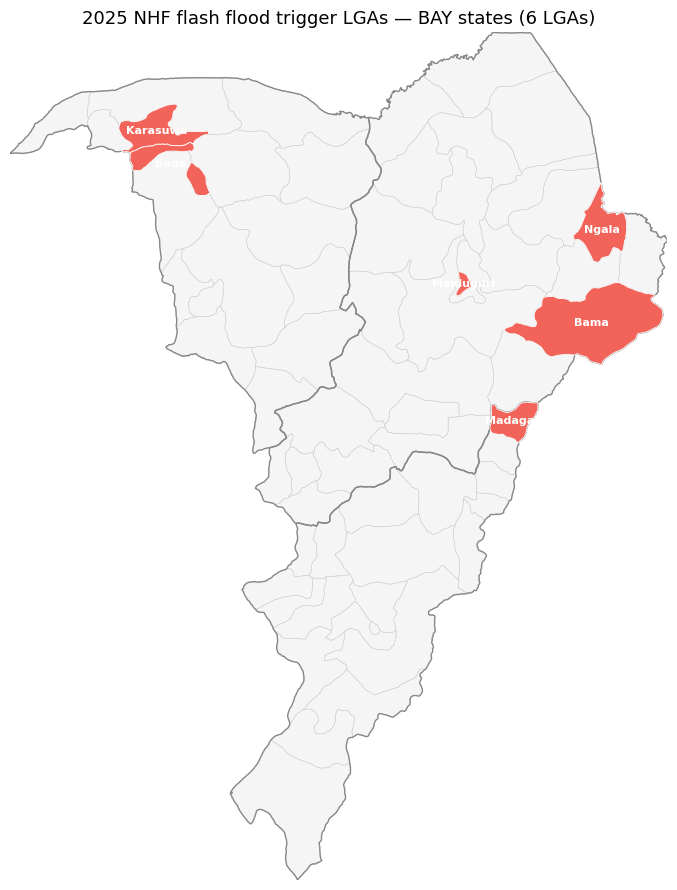

In [12]:
gdf_nhf = gdf_lga[gdf_lga["ADM2_PCODE"].isin(NHF_FLASH_LGAS)].copy()

print(f"2025 NHF flash trigger LGAs ({len(gdf_nhf)}):")
display(
    gdf_nhf[["ADM2_PCODE", "ADM2_EN", "ADM1_EN"]]
    .reset_index(drop=True)
    .sort_values("ADM1_EN")
)

fig, ax = plt.subplots(figsize=(10, 9))

gdf_bay.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=1.0)
gdf_nhf.plot(ax=ax, facecolor="#F2645A", edgecolor="white", linewidth=0.6, zorder=3)

for _, row in gdf_nhf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, row["ADM2_EN"],
        ha="center", va="center", fontsize=8, fontweight="bold",
        color="white", zorder=4,
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    f"2025 NHF flash flood trigger LGAs — BAY states ({len(gdf_nhf)} LGAs)",
    fontsize=13,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## CERF 01_geospatial_overview — OCHA Prioritized LGAs

In [13]:
# OCHA 2026 prioritized LGAs from cerf/01_geospatial_overview.ipynb
gdf_cerf_sel = stratus.load_geoparquet_from_blob(
    f"{PROJECT_PREFIX}/processed/selected_lgas_borno.parquet"
)

print(f"CERF selected LGAs: {len(gdf_cerf_sel)} total")
print(f"States: {gdf_cerf_sel['ADM1_EN'].value_counts().to_dict()}")

# Filter to BAY states only
gdf_cerf_bay = gdf_cerf_sel[gdf_cerf_sel["ADM1_EN"].isin(BAY_STATES)].copy()
print(f"\nIn BAY states: {len(gdf_cerf_bay)} LGAs")
display(
    gdf_cerf_bay[["ADM2_PCODE", "ADM2_EN", "ADM1_EN"]]
    .reset_index(drop=True)
    .sort_values(["ADM1_EN", "ADM2_EN"])
)

CERF selected LGAs: 16 total
States: {'Borno': 12, 'Yobe': 4}

In BAY states: 16 LGAs


,ADM2_PCODE,ADM2_EN,ADM1_EN
1,NG008008,Dikwa,Borno
2,NG008009,Gubio,Borno
5,NG008013,Jere,Borno
6,NG008014,Kaga,Borno
7,NG008015,Kala/Balge,Borno
8,NG008016,Konduga,Borno
9,NG008019,Mafa,Borno
10,NG008020,Magumeri,Borno
11,NG008021,Maiduguri,Borno
12,NG008023,Mobbar,Borno


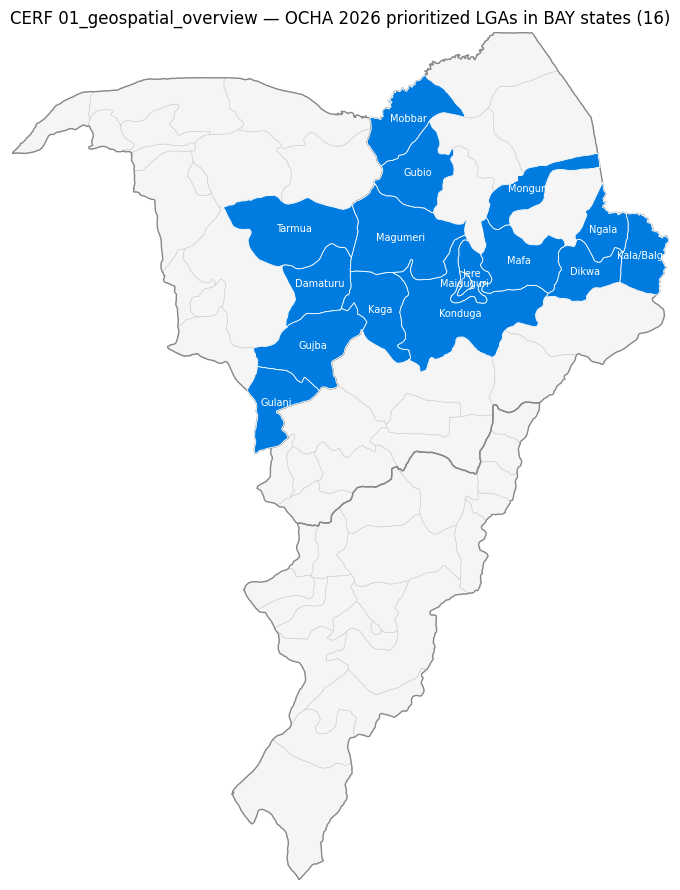

In [14]:
fig, ax = plt.subplots(figsize=(10, 9))

gdf_bay.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=1.0)
gdf_cerf_bay.plot(ax=ax, facecolor="#007CE0", edgecolor="white", linewidth=0.6, zorder=3)

for _, row in gdf_cerf_bay.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, row["ADM2_EN"],
        ha="center", va="center", fontsize=7, color="white", zorder=4,
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    f"CERF 01_geospatial_overview — OCHA 2026 prioritized LGAs in BAY states ({len(gdf_cerf_bay)})",
    fontsize=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Combined View — Overlap between 2025 trigger and CERF prioritized

In [15]:
nhf_pcodes  = set(gdf_nhf["ADM2_PCODE"])
cerf_pcodes = set(gdf_cerf_bay["ADM2_PCODE"])

overlap   = nhf_pcodes & cerf_pcodes
only_nhf  = nhf_pcodes - cerf_pcodes
only_cerf = cerf_pcodes - nhf_pcodes

def lga_name(pcode):
    return gdf_lga.loc[gdf_lga["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]

print(f"In BOTH 2025 trigger AND CERF prioritized ({len(overlap)}):")
for p in sorted(overlap, key=lga_name):
    print(f"  {lga_name(p)} ({p})")

print(f"\nIn 2025 trigger ONLY ({len(only_nhf)}):")
for p in sorted(only_nhf, key=lga_name):
    print(f"  {lga_name(p)} ({p})")

print(f"\nIn CERF prioritized ONLY ({len(only_cerf)}):")
for p in sorted(only_cerf, key=lga_name):
    print(f"  {lga_name(p)} ({p})")

In BOTH 2025 trigger AND CERF prioritized (2):
  Maiduguri (NG008021)
  Ngala (NG008025)

In 2025 trigger ONLY (4):
  Bade (NG036001)
  Bama (NG008003)
  Karasuwa (NG036010)
  Madagali (NG002010)

In CERF prioritized ONLY (14):
  Damaturu (NG036003)
  Dikwa (NG008008)
  Gubio (NG008009)
  Gujba (NG036007)
  Gulani (NG036008)
  Jere (NG008013)
  Kaga (NG008014)
  Kala/Balge (NG008015)
  Konduga (NG008016)
  Mafa (NG008019)
  Magumeri (NG008020)
  Mobbar (NG008023)
  Monguno (NG008024)
  Tarmua (NG036015)


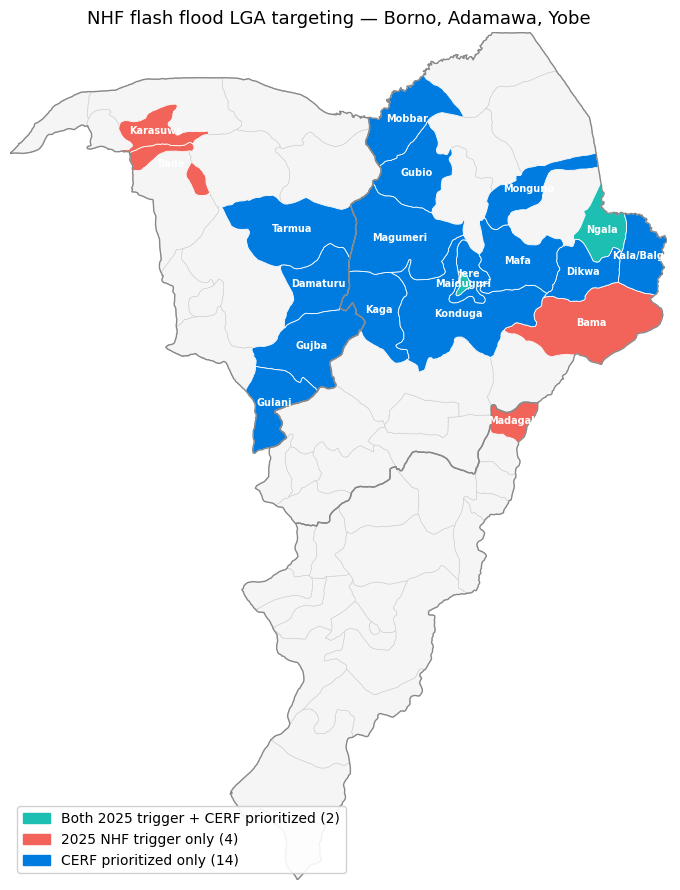

In [16]:
all_highlight = nhf_pcodes | cerf_pcodes

def classify(pcode):
    if pcode in overlap:
        return "both"
    if pcode in nhf_pcodes:
        return "nhf_only"
    if pcode in cerf_pcodes:
        return "cerf_only"
    return None

COLOR_MAP = {
    "both":      "#1EBFB3",  # teal
    "nhf_only":  "#F2645A",  # coral
    "cerf_only": "#007CE0",  # blue
}

gdf_combined = gdf_bay.copy()
gdf_combined["_class"] = gdf_combined["ADM2_PCODE"].apply(classify)
gdf_combined["_color"] = gdf_combined["_class"].map(COLOR_MAP)

gdf_bg  = gdf_combined[gdf_combined["_class"].isna()]
gdf_hl  = gdf_combined[gdf_combined["_class"].notna()]

fig, ax = plt.subplots(figsize=(10, 9))

gdf_bg.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=1.0, zorder=4)

for cls, color in COLOR_MAP.items():
    sub = gdf_hl[gdf_hl["_class"] == cls]
    if not sub.empty:
        sub.plot(ax=ax, facecolor=color, edgecolor="white", linewidth=0.6, zorder=3)

for _, row in gdf_hl.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, row["ADM2_EN"],
        ha="center", va="center", fontsize=7, fontweight="bold",
        color="white", zorder=5,
    )

legend_handles = [
    mpatches.Patch(color="#1EBFB3", label=f"Both 2025 trigger + CERF prioritized ({len(overlap)})"),
    mpatches.Patch(color="#F2645A", label=f"2025 NHF trigger only ({len(only_nhf)})"),
    mpatches.Patch(color="#007CE0", label=f"CERF prioritized only ({len(only_cerf)})"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=10, framealpha=0.9)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    "NHF flash flood LGA targeting — Borno, Adamawa, Yobe",
    fontsize=13,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## NiHSA High-Risk Communities (AFO 2026)

In [17]:
# Load NiHSA AFO at-risk communities
df_risk = stratus.load_csv_from_blob(
    "ds-aa-nga-flooding/raw/AA-nigeria_data/NiHSA/AFO_communities_atrisk_2026.csv"
)
df_risk["depth_zone"] = df_risk["depth_zone"].str.strip().str.capitalize()

gdf_risk = gpd.GeoDataFrame(
    df_risk,
    geometry=gpd.points_from_xy(df_risk["lon"], df_risk["lat"]),
    crs="EPSG:4326",
)

# Filter to BAY states
gdf_risk_bay = gdf_risk[gdf_risk.within(gdf_bay_adm1.union_all())].copy()
print(f"Communities within BAY states: {len(gdf_risk_bay):,}")
print(f"\nDepth zone breakdown:")
print(gdf_risk_bay["depth_zone"].value_counts().to_string())

Communities within BAY states: 7,210

Depth zone breakdown:
depth_zone
Medium    5545
High      1190
Low        475


Top 10 LGAs by high-risk community count:


,ADM2_EN,ADM1_EN,n_high_risk
0,Mobbar,Borno,377
1,Geidam,Yobe,207
2,Numan,Adamawa,125
3,Gubio,Borno,105
4,Yola North,Adamawa,102
5,Yunusari,Yobe,79
6,Demsa,Adamawa,58
7,Fufore,Adamawa,30
8,Shelleng,Adamawa,25
9,Yola South,Adamawa,25


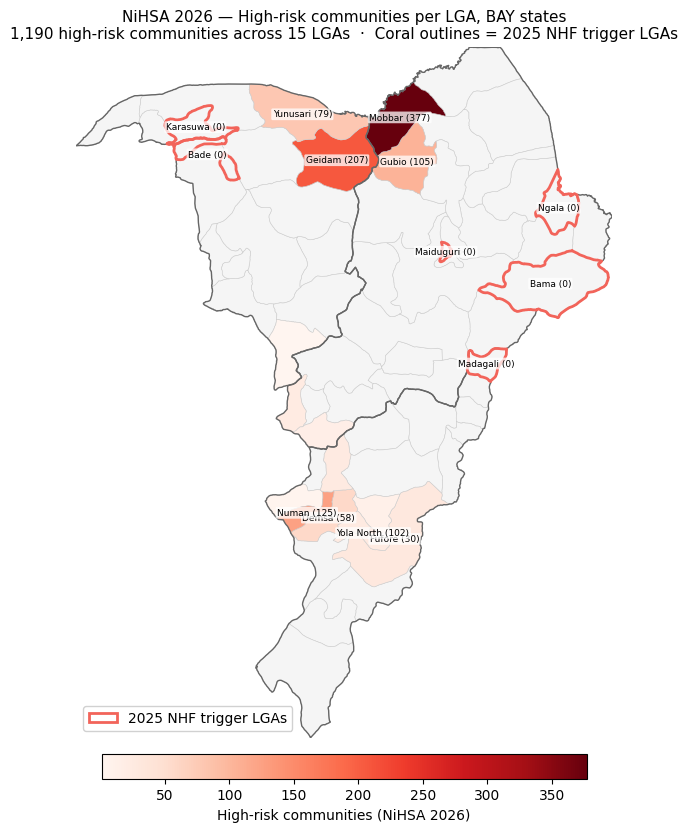

In [22]:
# Count High depth zone communities per LGA
gdf_high = gdf_risk_bay[gdf_risk_bay["depth_zone"] == "High"].copy()

gdf_high_lga = gpd.sjoin(
    gdf_high[["geometry"]],
    gdf_bay[["ADM2_PCODE", "ADM2_EN", "ADM1_EN", "geometry"]],
    how="inner",
    predicate="within",
)
df_high_counts = (
    gdf_high_lga.groupby("ADM2_PCODE")
    .size()
    .reset_index(name="n_high_risk")
)

gdf_map = gdf_bay.merge(df_high_counts, on="ADM2_PCODE", how="left")
gdf_map["n_high_risk"] = gdf_map["n_high_risk"].fillna(0).astype(int)

print(f"Top 10 LGAs by high-risk community count:")
display(
    gdf_map[["ADM2_EN", "ADM1_EN", "n_high_risk"]]
    .sort_values("n_high_risk", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# ── Choropleth with NHF trigger outlines overlaid ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

gdf_map[gdf_map["n_high_risk"] == 0].plot(
    ax=ax, facecolor="#f5f5f5", edgecolor="#cccccc", linewidth=0.4
)
gdf_map[gdf_map["n_high_risk"] > 0].plot(
    ax=ax,
    column="n_high_risk",
    cmap="Reds",
    edgecolor="#cccccc",
    linewidth=0.4,
    legend=True,
    legend_kwds={
        "label": "High-risk communities (NiHSA 2026)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.02,
    },
    zorder=2,
)
gdf_bay_adm1.plot(ax=ax, facecolor="none", edgecolor="#666666", linewidth=1.0, zorder=3)

# Outline 2025 NHF trigger LGAs
gdf_nhf.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=2.0, zorder=4)

# Label LGAs above the 85th percentile (or trigger LGAs) by name + count
label_threshold = gdf_map[gdf_map["n_high_risk"] > 0]["n_high_risk"].quantile(0.50)
gdf_label = gdf_map[
    (gdf_map["n_high_risk"] >= label_threshold) |
    (gdf_map["ADM2_PCODE"].isin(NHF_FLASH_LGAS))
].copy()

for _, row in gdf_label.iterrows():
    centroid = row.geometry.centroid
    count_str = f" ({row['n_high_risk']})" if row["n_high_risk"] > 0 else " (0)"
    ax.text(
        centroid.x, centroid.y,
        f"{row['ADM2_EN']}{count_str}",
        ha="center", va="center", fontsize=6.5, zorder=5,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
    )

legend_extra = [
    mpatches.Patch(facecolor="none", edgecolor="#F2645A", linewidth=2.0,
                   label="2025 NHF trigger LGAs"),
]
ax.legend(handles=legend_extra, loc="lower left", fontsize=10, framealpha=0.9)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    f"NiHSA 2026 — High-risk communities per LGA, BAY states\n"
    f"{len(gdf_high):,} high-risk communities across {(df_high_counts['n_high_risk'] > 0).sum()} LGAs  "
    f"·  Coral outlines = 2025 NHF trigger LGAs",
    fontsize=11,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/exploration/bay_states_high_risk_map.png", dpi=300)